# Matrix-Fractal Transmission vs Modern Data Standards

Этот notebook сравнивает передачу большого числа как payload-пакета через современные стандарты передачи данных и через матричное фрактальное представление.

Сценарий: есть большое целое число размера `N` бит. Его нужно передать как пакет данных.

Сравниваем:

- современные физические/пакетные стандарты: Ethernet, PCI Express, USB4, Thunderbolt;
- традиционные двоичные baseline-схемы с разным числом физических каналов;
- фрактальную передачу, где разряды кодируются матрицей `period x shift`, а логические каналы схлопываются в один наблюдаемый событийный поток.

Главные метрики:

- **latency ticks** - нормализованное число последовательных тактов/символов;
- **physical streams** - число физических линий, lanes или наблюдаемых потоков;
- **stream-ticks** - `latency ticks * physical streams`;
- **efficiency** - полезные биты на один такт одного физического потока.

Важно: абсолютное время для Ethernet/PCIe/USB/TB можно оценивать по опубликованной пропускной способности. Для фрактальной схемы пока сравниваем нормализованные событийные такты, потому что её физическая частота ещё не задана.

In [1]:
from pathlib import Path
import sys
import math

ROOT = Path.cwd()
if (ROOT / "snn_framework").exists():
    sys.path.insert(0, str(ROOT))
elif (ROOT.parent / "snn_framework").exists():
    sys.path.insert(0, str(ROOT.parent))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
from snn_framework import MatrixFractalNumber

pd.set_option("display.max_columns", 30)
pd.set_option("display.width", 180)
plt.style.use("seaborn-v0_8-whitegrid")


def show_table(df, caption=None, precision=2):
    styler = (
        df.style.hide(axis="index")
        .format(precision=precision)
        .set_table_styles([
            {"selector": "caption", "props": [("caption-side", "top"), ("font-weight", "bold"), ("font-size", "14px")]},
            {"selector": "th", "props": [("text-align", "center"), ("background-color", "#f2f4f8")]},
            {"selector": "td", "props": [("text-align", "center"), ("padding", "6px 10px")]},
        ])
    )
    if caption:
        styler = styler.set_caption(caption)
    display(styler)


def build_model(period_levels, shift_levels):
    return MatrixFractalNumber(
        period_levels=period_levels,
        shift_levels=shift_levels,
        base_period_ticks=max(8, shift_levels),
    )


def ceil_div(a, b):
    return int(math.ceil(a / b))


def binary_latency_ticks(payload_bits, physical_streams, bits_per_stream_tick=1.0, overhead_bits=0, packet_unit_bits=0):
    encoded_bits = payload_bits + overhead_bits
    if packet_unit_bits:
        encoded_bits = ceil_div(encoded_bits, packet_unit_bits) * packet_unit_bits
    return int(math.ceil(encoded_bits / (physical_streams * bits_per_stream_tick)))


def fractal_latency_ticks(payload_bits, period_levels, shift_levels):
    model = build_model(period_levels, shift_levels)
    return int(math.ceil(payload_bits / math.log2(model.base)))


def ns_from_gbps(bits, gbps):
    return bits / gbps if gbps and not np.isnan(gbps) else np.nan


def short_num(bits):
    if bits < 8_192:
        return f"{bits} bit"
    if bits < 8_388_608:
        return f"{bits / 8_192:.0f} KiB"
    return f"{bits / 8_388_608:.0f} MiB"

## Block 1. Modern Data Transmission Standards

**Что тестируется.** Фиксируем инженерную базу сравнения: какие современные стандарты используют много lanes, многоуровневую модуляцию и пакетизацию.

Здесь важно не смешивать два уровня:

- стандарт связи даёт физическую пропускную способность за счёт частоты, lanes и PAM-модуляции;
- фрактальное число предлагает другой способ представления данных: больше информации в одном событийном символе и один наблюдаемый поток вместо множества логических разрядных каналов.

In [2]:
standards = pd.DataFrame([
    {"method": "binary serial baseline", "family": "baseline", "status": "reference", "payload Gbps": np.nan, "physical streams": 1, "signaling": "binary NRZ", "bits / stream tick": 1.0, "packet unit bits": 0, "overhead bits": 0, "comment": "one bit per tick on one physical stream"},
    {"method": "binary parallel x8", "family": "baseline", "status": "reference", "payload Gbps": np.nan, "physical streams": 8, "signaling": "binary NRZ", "bits / stream tick": 1.0, "packet unit bits": 0, "overhead bits": 0, "comment": "eight independent binary streams"},
    {"method": "800G Ethernet DR8", "family": "Ethernet", "status": "IEEE 802.3df / modern", "payload Gbps": 800, "physical streams": 8, "signaling": "PAM4", "bits / stream tick": 2.0, "packet unit bits": 0, "overhead bits": 38 * 8, "comment": "8 lanes; simplified Ethernet framing overhead"},
    {"method": "1.6T Ethernet draft", "family": "Ethernet", "status": "IEEE 802.3dj draft / emerging", "payload Gbps": 1600, "physical streams": 8, "signaling": "PAM4 / 200G lanes", "bits / stream tick": 2.0, "packet unit bits": 0, "overhead bits": 38 * 8, "comment": "draft comparison point, not deployed baseline"},
    {"method": "PCIe 6.0 x16", "family": "PCI Express", "status": "released spec", "payload Gbps": 1024, "physical streams": 16, "signaling": "PAM4 + FLIT", "bits / stream tick": 2.0, "packet unit bits": 256 * 8, "overhead bits": 0, "comment": "one direction of x16 link; FLIT-rounded model"},
    {"method": "PCIe 7.0 x16", "family": "PCI Express", "status": "released spec / 2025", "payload Gbps": 2048, "physical streams": 16, "signaling": "PAM4 + FLIT", "bits / stream tick": 2.0, "packet unit bits": 256 * 8, "overhead bits": 0, "comment": "one direction of x16 link; products expected after spec release"},
    {"method": "USB4 v2 80G", "family": "USB4", "status": "published spec", "payload Gbps": 80, "physical streams": 2, "signaling": "PAM3", "bits / stream tick": math.log2(3), "packet unit bits": 0, "overhead bits": 0, "comment": "two high-speed lanes in one direction; normalized PAM3 model"},
    {"method": "Thunderbolt 5 boost", "family": "Thunderbolt", "status": "modern consumer interconnect", "payload Gbps": 120, "physical streams": 3, "signaling": "PAM3", "bits / stream tick": math.log2(3), "packet unit bits": 0, "overhead bits": 0, "comment": "asymmetric 120 Gbps direction; normalized PAM3 model"},
])

show_table(standards, "Reference standards and simplified normalized channel model")

method,family,status,payload Gbps,physical streams,signaling,bits / stream tick,packet unit bits,overhead bits,comment
binary serial baseline,baseline,reference,nan,1,binary NRZ,1.00,0,0,one bit per tick on one physical stream
binary parallel x8,baseline,reference,nan,8,binary NRZ,1.00,0,0,eight independent binary streams
800G Ethernet DR8,Ethernet,IEEE 802.3df / modern,800.00,8,PAM4,2.00,0,304,8 lanes; simplified Ethernet framing overhead
1.6T Ethernet draft,Ethernet,IEEE 802.3dj draft / emerging,1600.00,8,PAM4 / 200G lanes,2.00,0,304,"draft comparison point, not deployed baseline"
PCIe 6.0 x16,PCI Express,released spec,1024.00,16,PAM4 + FLIT,2.00,2048,0,one direction of x16 link; FLIT-rounded model
PCIe 7.0 x16,PCI Express,released spec / 2025,2048.00,16,PAM4 + FLIT,2.00,2048,0,one direction of x16 link; products expected after spec release
USB4 v2 80G,USB4,published spec,80.00,2,PAM3,1.58,0,0,two high-speed lanes in one direction; normalized PAM3 model
Thunderbolt 5 boost,Thunderbolt,modern consumer interconnect,120.00,3,PAM3,1.58,0,0,asymmetric 120 Gbps direction; normalized PAM3 model


### Вывод по блоку 1

Современные стандарты уже не являются “просто двоичной линией”. Они используют много lanes, PAM3/PAM4, FLIT/packet framing и огромные физические частоты.

Но почти все они масштабируют передачу через больше физических lanes и более быструю физику. Фрактальный вариант проверяется как другой тип выигрыша: более ёмкий событийный символ и один наблюдаемый поток.

## Block 2. Packet Model: Big Integer Payload

**Что тестируется.** Моделируем передачу большого целого числа как payload-пакета разных размеров.

Размеры выбраны от `1 KiB` до `16 MiB`. Для стандартов считаем нормализованные symbol ticks. Для фрактального числа считаем, что один событийный символ переносит `log2(period_levels * shift_levels)` бит состояния.

In [3]:
payload_sizes_bits = [1 * 1024 * 8, 4 * 1024 * 8, 64 * 1024 * 8, 1 * 1024 * 1024 * 8, 16 * 1024 * 1024 * 8]
fractal_configs = [(8, 8), (16, 16), (32, 32), (64, 64)]
rows = []

for payload_bits in payload_sizes_bits:
    for _, standard in standards.iterrows():
        ticks = binary_latency_ticks(payload_bits, standard["physical streams"], standard["bits / stream tick"], standard["overhead bits"], standard["packet unit bits"])
        channel_ticks = ticks * standard["physical streams"]
        encoded_bits = payload_bits + standard["overhead bits"]
        if standard["packet unit bits"]:
            encoded_bits = ceil_div(encoded_bits, standard["packet unit bits"]) * standard["packet unit bits"]
        rows.append({
            "payload bits": payload_bits,
            "payload": short_num(payload_bits),
            "method": standard["method"],
            "family": standard["family"],
            "physical streams": standard["physical streams"],
            "symbol capacity": standard["bits / stream tick"],
            "latency ticks": ticks,
            "stream-ticks": channel_ticks,
            "efficiency bits / stream-tick": payload_bits / channel_ticks,
            "estimated time ns": ns_from_gbps(encoded_bits, standard["payload Gbps"]),
        })

    for period_levels, shift_levels in fractal_configs:
        model = build_model(period_levels, shift_levels)
        symbol_capacity = math.log2(model.base)
        ticks = fractal_latency_ticks(payload_bits, period_levels, shift_levels)
        rows.append({
            "payload bits": payload_bits,
            "payload": short_num(payload_bits),
            "method": f"fractal {period_levels}x{shift_levels}",
            "family": "matrix fractal",
            "physical streams": 1,
            "symbol capacity": symbol_capacity,
            "latency ticks": ticks,
            "stream-ticks": ticks,
            "efficiency bits / stream-tick": payload_bits / ticks,
            "estimated time ns": np.nan,
        })

comparison = pd.DataFrame(rows)
selected_methods = ["binary serial baseline", "binary parallel x8", "800G Ethernet DR8", "PCIe 7.0 x16", "USB4 v2 80G", "Thunderbolt 5 boost", "fractal 8x8", "fractal 32x32", "fractal 64x64"]
show_table(comparison[comparison["method"].isin(selected_methods)], "Packet transmission model: modern standards vs matrix-fractal representation")

payload bits,payload,method,family,physical streams,symbol capacity,latency ticks,stream-ticks,efficiency bits / stream-tick,estimated time ns
8192,1 KiB,binary serial baseline,baseline,1,1.00,8192,8192,1.00,nan
8192,1 KiB,binary parallel x8,baseline,8,1.00,1024,8192,1.00,nan
8192,1 KiB,800G Ethernet DR8,Ethernet,8,2.00,531,4248,1.93,10.62
8192,1 KiB,PCIe 7.0 x16,PCI Express,16,2.00,256,4096,2.00,4.00
8192,1 KiB,USB4 v2 80G,USB4,2,1.58,2585,5170,1.58,102.40
8192,1 KiB,Thunderbolt 5 boost,Thunderbolt,3,1.58,1723,5169,1.58,68.27
8192,1 KiB,fractal 8x8,matrix fractal,1,6.00,1366,1366,6.00,nan
8192,1 KiB,fractal 32x32,matrix fractal,1,10.00,820,820,9.99,nan
8192,1 KiB,fractal 64x64,matrix fractal,1,12.00,683,683,11.99,nan
32768,4 KiB,binary serial baseline,baseline,1,1.00,32768,32768,1.00,nan


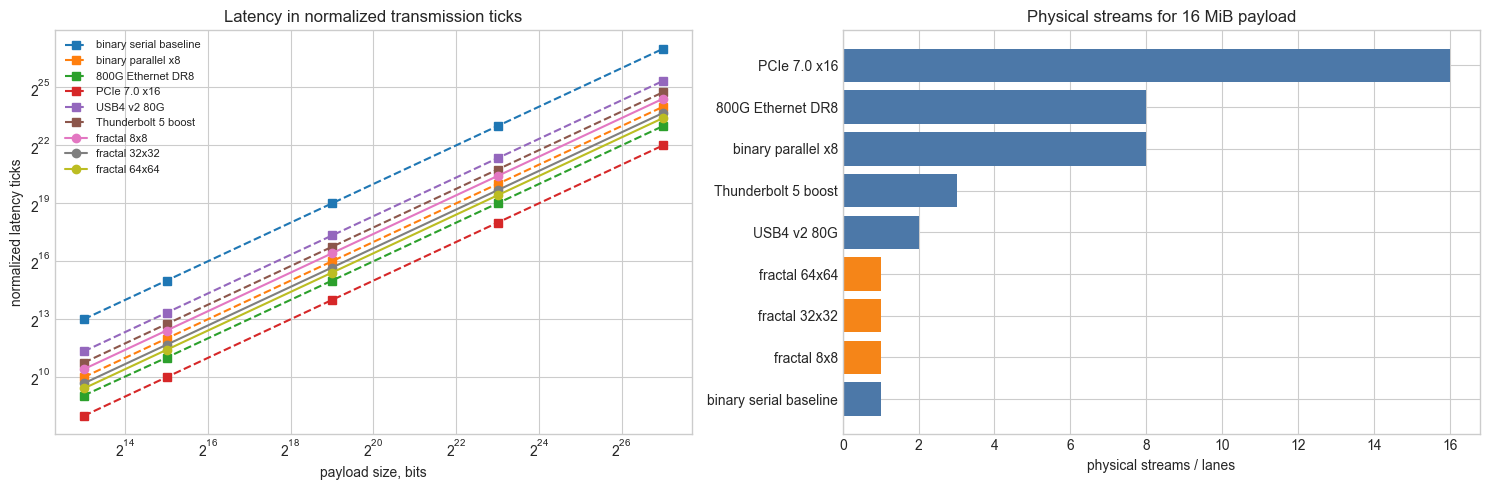

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

for method in selected_methods:
    group = comparison[comparison["method"] == method]
    is_fractal = method.startswith("fractal")
    axes[0].plot(group["payload bits"], group["latency ticks"], marker="o" if is_fractal else "s", linestyle="-" if is_fractal else "--", label=method)

axes[0].set_xlabel("payload size, bits")
axes[0].set_ylabel("normalized latency ticks")
axes[0].set_xscale("log", base=2)
axes[0].set_yscale("log", base=2)
axes[0].set_title("Latency in normalized transmission ticks")
axes[0].legend(fontsize=8)

stream_snapshot = comparison[(comparison["payload bits"] == payload_sizes_bits[-1]) & (comparison["method"].isin(selected_methods))].sort_values("physical streams")
colors = ["#F58518" if method.startswith("fractal") else "#4C78A8" for method in stream_snapshot["method"]]
axes[1].barh(stream_snapshot["method"], stream_snapshot["physical streams"], color=colors)
axes[1].set_xlabel("physical streams / lanes")
axes[1].set_title(f"Physical streams for {short_num(payload_sizes_bits[-1])} payload")

plt.tight_layout()
plt.show()

### Вывод по блоку 2

Если смотреть только на latency, современные стандарты сильны за счёт физической параллельности и огромной скорости: Ethernet/PCIe используют много lanes, а PCIe x16 особенно агрессивно параллелит передачу.

Фрактальная схема в нормализованных тактах выигрывает иначе: она не добавляет lanes, а увеличивает информационную ёмкость одного события. Поэтому у неё `physical streams = 1`, но latency падает по мере роста основания матрицы.

## Block 3. Final Efficiency Metric

**Что тестируется.** Вводим итоговую метрику эффективности передачи:

```text
efficiency = useful_payload_bits / (latency_ticks * physical_streams)
```

Метрика показывает, сколько полезных бит приходится на один такт одного физического потока.

Для обычной двоичной линии потолок около `1 bit / stream-tick`. Для PAM4 - около `2`. Для PAM3 - около `log2(3)`. Для фрактального события потолок равен `log2(matrix_base)`.

In [5]:
efficiency_table = comparison[comparison["method"].isin(selected_methods)][["payload", "method", "physical streams", "symbol capacity", "latency ticks", "stream-ticks", "efficiency bits / stream-tick"]].copy()
show_table(efficiency_table, "Final efficiency metric: useful bits per physical stream tick")

payload,method,physical streams,symbol capacity,latency ticks,stream-ticks,efficiency bits / stream-tick
1 KiB,binary serial baseline,1,1.00,8192,8192,1.00
1 KiB,binary parallel x8,8,1.00,1024,8192,1.00
1 KiB,800G Ethernet DR8,8,2.00,531,4248,1.93
1 KiB,PCIe 7.0 x16,16,2.00,256,4096,2.00
1 KiB,USB4 v2 80G,2,1.58,2585,5170,1.58
1 KiB,Thunderbolt 5 boost,3,1.58,1723,5169,1.58
1 KiB,fractal 8x8,1,6.00,1366,1366,6.00
1 KiB,fractal 32x32,1,10.00,820,820,9.99
1 KiB,fractal 64x64,1,12.00,683,683,11.99
4 KiB,binary serial baseline,1,1.00,32768,32768,1.00


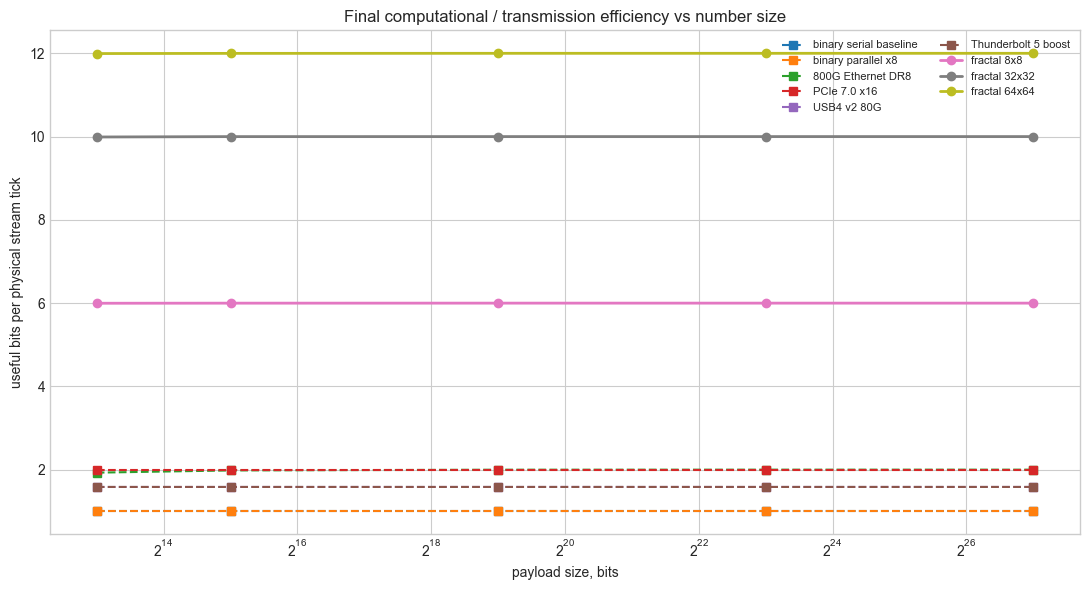

In [6]:
fig, ax = plt.subplots(figsize=(11, 6))

for method in selected_methods:
    group = comparison[comparison["method"] == method]
    is_fractal = method.startswith("fractal")
    ax.plot(group["payload bits"], group["efficiency bits / stream-tick"], marker="o" if is_fractal else "s", linestyle="-" if is_fractal else "--", linewidth=2 if is_fractal else 1.5, label=method)

ax.set_xlabel("payload size, bits")
ax.set_ylabel("useful bits per physical stream tick")
ax.set_xscale("log", base=2)
ax.set_title("Final computational / transmission efficiency vs number size")
ax.legend(fontsize=8, ncol=2)
plt.tight_layout()
plt.show()

### Вывод по блоку 3

Итоговый график показывает главное отличие.

Современные стандарты поднимают пропускную способность за счёт физики: частота, lanes, PAM3/PAM4, FLIT/packet processing. Но в пересчёте на один такт одного физического потока их информационная плотность ограничена модуляцией.

Фрактальная схема задаёт более крупный алфавит события. Для `8x8` это `6` бит на stream-tick, для `32x32` - `10`, для `64x64` - `12`. Поэтому её нормализованная эффективность выше именно как эффективность представления.

## Block 4. Gain Against Modern Standards

**Что тестируется.** Считаем коэффициенты выигрыша фрактальной передачи относительно выбранных современных стандартов.

- **latency gain**: во сколько раз меньше нормализованных последовательных тактов;
- **stream efficiency gain**: во сколько раз больше полезных бит на один такт одного физического потока.

Latency gain против PCIe может быть скромнее, потому что PCIe x16 использует 16 физических lanes. Но stream efficiency показывает другую сторону: фрактальное представление достигает высокой плотности в одном наблюдаемом потоке.

In [7]:
reference_methods = ["800G Ethernet DR8", "PCIe 7.0 x16", "USB4 v2 80G", "Thunderbolt 5 boost"]
fractal_methods = ["fractal 8x8", "fractal 32x32", "fractal 64x64"]
gain_rows = []

for payload_bits in payload_sizes_bits:
    for reference in reference_methods:
        ref_row = comparison[(comparison["payload bits"] == payload_bits) & (comparison["method"] == reference)].iloc[0]
        for fractal in fractal_methods:
            frac_row = comparison[(comparison["payload bits"] == payload_bits) & (comparison["method"] == fractal)].iloc[0]
            gain_rows.append({
                "payload": short_num(payload_bits),
                "reference": reference,
                "fractal": fractal,
                "latency gain": ref_row["latency ticks"] / frac_row["latency ticks"],
                "stream efficiency gain": frac_row["efficiency bits / stream-tick"] / ref_row["efficiency bits / stream-tick"],
                "reference streams": ref_row["physical streams"],
                "fractal streams": frac_row["physical streams"],
            })

gains = pd.DataFrame(gain_rows)
show_table(gains, "Gain coefficients: matrix-fractal representation vs modern standards")

payload,reference,fractal,latency gain,stream efficiency gain,reference streams,fractal streams
1 KiB,800G Ethernet DR8,fractal 8x8,0.39,3.11,8,1
1 KiB,800G Ethernet DR8,fractal 32x32,0.65,5.18,8,1
1 KiB,800G Ethernet DR8,fractal 64x64,0.78,6.22,8,1
1 KiB,PCIe 7.0 x16,fractal 8x8,0.19,3.00,16,1
1 KiB,PCIe 7.0 x16,fractal 32x32,0.31,5.00,16,1
1 KiB,PCIe 7.0 x16,fractal 64x64,0.37,6.00,16,1
1 KiB,USB4 v2 80G,fractal 8x8,1.89,3.78,2,1
1 KiB,USB4 v2 80G,fractal 32x32,3.15,6.30,2,1
1 KiB,USB4 v2 80G,fractal 64x64,3.78,7.57,2,1
1 KiB,Thunderbolt 5 boost,fractal 8x8,1.26,3.78,3,1


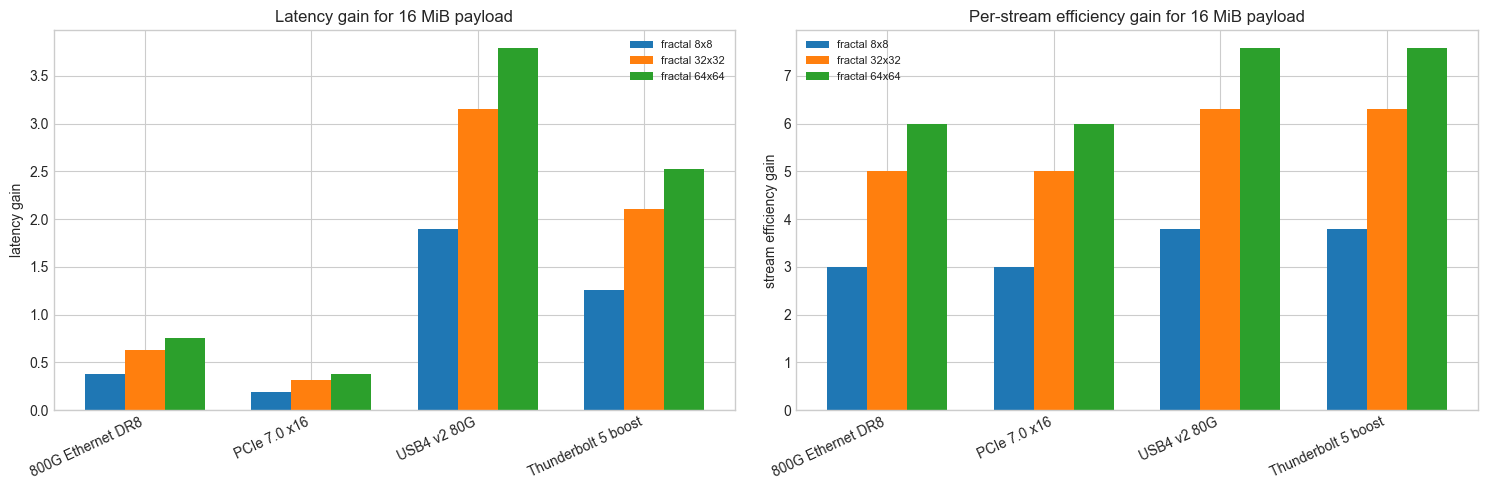

In [8]:
target_payload = payload_sizes_bits[-1]
gain_plot = gains[gains["payload"] == short_num(target_payload)]
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

x = np.arange(len(reference_methods))
width = 0.24
for idx, fractal in enumerate(fractal_methods):
    group = gain_plot[gain_plot["fractal"] == fractal]
    axes[0].bar(x + width * idx, group["latency gain"], width=width, label=fractal)
axes[0].set_xticks(x + width)
axes[0].set_xticklabels(reference_methods, rotation=25, ha="right")
axes[0].set_ylabel("latency gain")
axes[0].set_title(f"Latency gain for {short_num(target_payload)} payload")
axes[0].legend(fontsize=8)

for idx, fractal in enumerate(fractal_methods):
    group = gain_plot[gain_plot["fractal"] == fractal]
    axes[1].bar(x + width * idx, group["stream efficiency gain"], width=width, label=fractal)
axes[1].set_xticks(x + width)
axes[1].set_xticklabels(reference_methods, rotation=25, ha="right")
axes[1].set_ylabel("stream efficiency gain")
axes[1].set_title(f"Per-stream efficiency gain for {short_num(target_payload)} payload")
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.show()

### Вывод по блоку 4

Фрактальная схема не обязана побеждать все современные стандарты по абсолютной latency, если стандарт использует много физических lanes и огромную частоту. Например, PCIe x16 агрессивно параллелит передачу.

Но фрактальная схема показывает сильный выигрыш по **плотности одного потока**: вместо множества физических lanes она использует один наблюдаемый событийный поток, где символ имеет высокое основание.

## Block 5. Why The Result Looks This Way

Теперь объясняем, почему сравнение даёт именно такую картину.

### 1. Современные стандарты выигрывают физикой

Ethernet, PCIe, USB4 и Thunderbolt увеличивают throughput через больше lanes, выше частоту, PAM3/PAM4, пакетизацию, FLIT, FEC/CRC и сложную физику канала.

### 2. Фрактальная схема выигрывает представлением

Матричное фрактальное число кодирует разряд не высотой сигнала, а выбранной ячейкой:

```text
digit -> (period_index, shift_index)
base = period_levels * shift_levels
```

Один событийный символ переносит `log2(period_levels * shift_levels)` бит состояния.

### 3. Каналы разрядов схлопываются в один поток

Логически у числа много digit-каналов. Но физически они могут наблюдаться как один суммарный амплитудный поток:

```text
total_signal(t) = sum(channel_i(t))
```

Разделение каналов переносится из отдельных проводов/lanes в известную временную структуру: периоды, сдвиги и окна активности.

In [9]:
explanation_rows = []
for period_levels, shift_levels in fractal_configs:
    model = build_model(period_levels, shift_levels)
    explanation_rows.append({
        "matrix": f"{period_levels}x{shift_levels}",
        "base": model.base,
        "bits per event symbol": math.log2(model.base),
        "physical observed streams": 1,
        "why efficient": "high-radix event + collapsed digit channels",
    })

show_table(pd.DataFrame(explanation_rows), "Fractal event alphabet capacity")

matrix,base,bits per event symbol,physical observed streams,why efficient
8x8,64,6.00,1,high-radix event + collapsed digit channels
16x16,256,8.00,1,high-radix event + collapsed digit channels
32x32,1024,10.00,1,high-radix event + collapsed digit channels
64x64,4096,12.00,1,high-radix event + collapsed digit channels


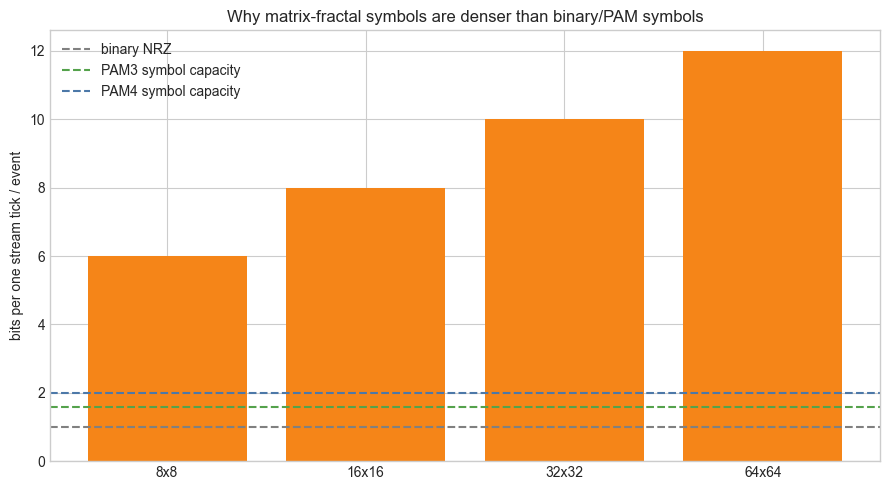

In [10]:
fig, ax = plt.subplots(figsize=(9, 5))
matrices = [f"{p}x{s}" for p, s in fractal_configs]
bits_per_symbol = [math.log2(p * s) for p, s in fractal_configs]

ax.bar(matrices, bits_per_symbol, color="#F58518")
ax.axhline(1, color="gray", linestyle="--", label="binary NRZ")
ax.axhline(math.log2(3), color="#54A24B", linestyle="--", label="PAM3 symbol capacity")
ax.axhline(2, color="#4C78A8", linestyle="--", label="PAM4 symbol capacity")
ax.set_ylabel("bits per one stream tick / event")
ax.set_title("Why matrix-fractal symbols are denser than binary/PAM symbols")
ax.legend()
plt.tight_layout()
plt.show()

## Final Conclusion

Итоговая логика notebook:

1. Современные стандарты передачи данных очень сильны, но их сила в физическом throughput: lanes, частота, PAM-модуляция, пакетизация и коррекция ошибок.
2. Если сравнивать абсолютное время, реальные стандарты пока имеют преимущество, потому что они физически реализованы и работают на огромных скоростях.
3. Если сравнивать нормализованную эффективность представления, фрактальная схема показывает другой источник выигрыша: один событийный символ несёт много бит состояния.
4. Если добавить схлопывание digit-каналов в один наблюдаемый поток, фрактальное представление становится особенно интересным для SNN-памяти и событийных адресов.

**Ключевой тезис:** фрактальная передача не просто “сжимает число”. Она меняет алфавит передачи: вместо плоского двоичного бита используется событийный символ с периодом, фазой/сдвигом и окном активности.

### Использованные инженерные ориентиры

- 800G Ethernet: IEEE 802.3df, 8-lane PAM4 class.
- 1.6T Ethernet: IEEE 802.3dj draft/emerging comparison point.
- PCIe 6.0: 64 GT/s PAM4, FLIT-based encoding.
- PCIe 7.0: 128 GT/s PAM4, final specification released in 2025.
- USB4 v2: 80 Gbps class, PAM3 signaling.
- Thunderbolt 5: 80 Gbps bidirectional / 120 Gbps boost class, PAM3 signaling.

Числа в notebook являются исследовательской моделью, а не полной PHY-симуляцией стандарта. Для полной инженерной оценки нужно добавить реальные line coding overhead, FEC, CRC, packet scheduling, clock frequency, BER и decoder cost.